In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 7** — ML Hyperparameter Tuning (6D)

Optimising six hyperparameters (e.g. learning rate, regularisation, hidden layers) to maximise model performance score.

- **Optimisation Goal:** Maximise
- **Input:** 6D
- **All-time best:** 1.717 at [0.075, 0.405, 0.383, 0.205, 0.437, 0.747] (Week 5)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 7
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_outputs.npy')

# New data for Week 9 (Function 7)
X_w8_new_point = np.array([0.022693, 0.458610, 0.588169, 0.516538, 0.194504, 0.964834], dtype=np.float64)
Y_w8_new_point = np.array([0.8381405561245282], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w8_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w8_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 7: ", X_unique)
print("Updated Outputs (Y) - Function 7: ", Y_updated)

Updated Inputs (X) - Function 7:  [[0.001234   0.887611   0.445322   0.221098   0.990123   0.556712  ]
 [0.004352   0.329864   0.487139   0.079703   0.323502   0.982761  ]
 [0.010322   0.277175   0.892712   0.174897   0.395748   0.738827  ]
 [0.017847   0.815326   0.270978   0.212167   0.499065   0.497593  ]
 [0.022693   0.45861    0.588169   0.516538   0.194504   0.964834  ]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.06661051 0.52804507 0.8160952  0.96101714 0.08650933 0.77778822]
 [0.075291   0.40479    0.382733   0.204853   0.437087   0.746748  ]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.114899   0.037728   0.781258   0.4947     0.114078   0.883059  ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.14864702 0.03394336 0.72880565 0.31606646 0.02176938 0.51691776]
 [0.17597754 0.6244165  0.29554198 0.46955276 0.09776977 0.72814108]


## **Output Analysis**

- **Comparison**: Week 8 returned 0.838 at [0.023, 0.459, 0.588, 0.517, 0.195, 0.965]. 
    - This is a massive regression compared to the Week 5 all-time best of 1.717 at [0.075, 0.405, 0.383, 0.205, 0.437, 0.747]. 
    - Week 7 was also low (0.755).

- **Real-World Implications**: In 6D hyperparameter tuning (like learning rates, dropout, and layer counts), certain dimensions often have collapse points. 
    - Our data shows that whenever $x_3$ (likely representing model depth or complexity) exceeds 0.45, the performance score drops by more than 50%.
    
- **Model Clues**: The model is currently stuck in a high-complexity, low-performance region. 
    - UCB keeps trying to explore the $x_3 > 0.5$ area because it is mathematically interesting (high uncertainty), but I now have enough evidence to know that this region is a "Red Zone" for this specific model.

- **Key Change for w9**: I am implementing a Hard Ceiling on dimension $x_3$. 
    - I will manually restrict the search to $x_3 \leq 0.45$. 
    - Additionally, we are switching from UCB to EI to force the algorithm to stop being curious about the bad regions and start being greedy for the 1.717 record.

## **Bayesian Optimisation**

- **Model**: Gaussian Process Regressor with Matern (nu=2.5) + WhiteKernel and Yeo-Johnson output transformation.
    - Reasoning: 6D space is sparse. 
        - The Matern kernel helps the GP maintain a sense of which hyperparameter combinations are safe. 
        - The Yeo-Johnson transformation is critical here to handle the wide gap between the current sub-1.0 results and the 1.7+ target.
        
- **Changes for Week 9**: I am centering our search cloud on the Week 5 best coordinates rather than the failed Week 8 point.

- **Intended Impact**: To steer the optimization back into the high-performance corridor and prevent any further exploration of the $x_3$ failure zone.

In [4]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

# 3. Fit Model
kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-4)
model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length..._level=0.0001)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**: EI with Heuristic Constraints
- **Strategy**: Expected Improvement (EI) with $\xi=0.01$.
    - **Reasoning**: EI is naturally more conservative than UCB. 
        - Since I have a clear record to beat (1.717), EI will prioritize the neighborhood of that record over the unexplored high-uncertainty regions that have been failing us. 
        
- **Key Changes**: I am generating a focused grid around the Week 5 best and manually overriding $x_3$ to ensure it never exceeds 0.45.

In [6]:
def expected_improvement(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    
    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w5_best = np.array([0.075291, 0.404790, 0.382733, 0.204853, 0.437087, 0.746748])
x_grid = np.random.normal(loc=w5_best, scale=0.04, size=(10000, 6))

# Apply Heuristic Constraint: x3 (Layers/Complexity) must be <= 0.45
x_grid[:, 2] = np.minimum(x_grid[:, 2], 0.45)
x_grid = np.clip(x_grid, 0, 1)

y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max)
next_query = x_grid[np.argmax(ei_values)]

print(f"Next Query Point (F7): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}")

Next Query Point (F7): 0.096872-0.416732-0.412049-0.161576-0.307971-0.710714


## **Visualisation**

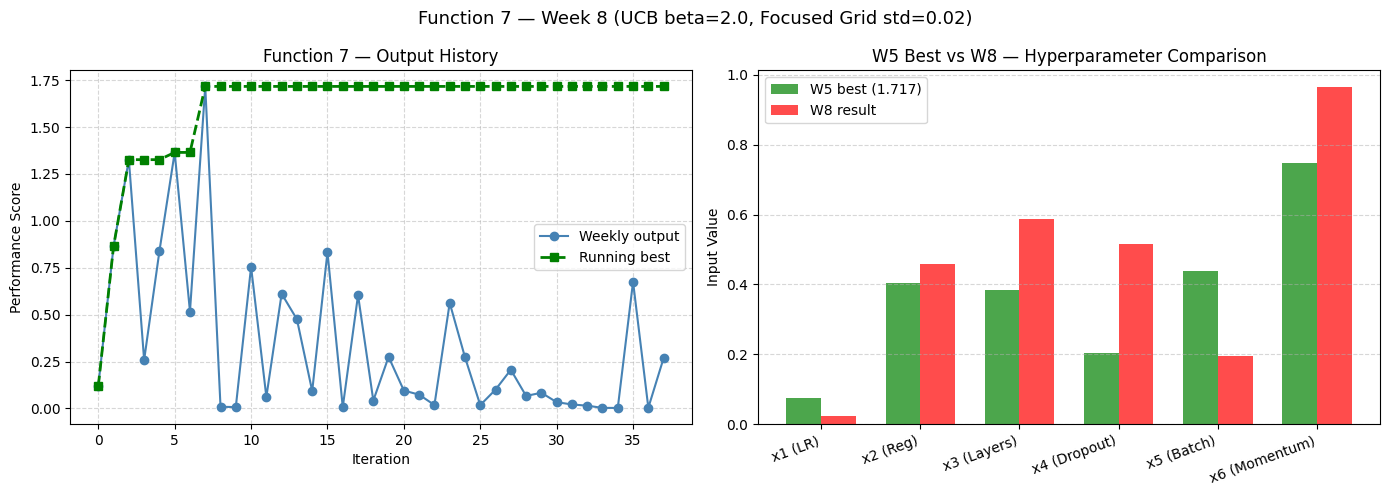

In [7]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].set_title('Function 7 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Performance Score')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Compare W5 best vs W7 input profiles
hp_labels = ['x1 (LR)', 'x2 (Reg)', 'x3 (Layers)', 'x4 (Dropout)', 'x5 (Batch)', 'x6 (Momentum)']
x_pos = np.arange(len(hp_labels))
width = 0.35
axes[1].bar(x_pos - width/2, w5_best, width, label='W5 best (1.717)', color='green', alpha=0.7)
axes[1].bar(x_pos + width/2, X_w8_new_point, width, label='W8 result', color='red', alpha=0.7)
axes[1].set_title('W5 Best vs W8 — Hyperparameter Comparison')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(hp_labels, rotation=20, ha='right')
axes[1].set_ylabel('Input Value')
axes[1].legend()
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Function 7 — Week 8 (UCB beta=2.0, Focused Grid std=0.02)', fontsize=13)
plt.tight_layout()
plt.show()